# Task 4: Statistical Modeling & Risk-Based Pricing

This notebook implements predictive modeling and dynamic premium optimization to form the core of a risk-based pricing framework for ACIS.

## Objectives:
1. **Claim Severity Prediction**: Estimate the financial liability (total claims) when a claim occurs.
2. **Claim Probability Prediction**: Estimate the likelihood of a policy having a claim.
3. **Premium Optimization**: Combine both predictions into a dynamic pricing formula:
   $$\text{Premium} = (P(\text{claim}) \times \text{Predicted Severity}) + \text{Expense Loading} + \text{Profit Margin}$$
4. **Interpretability**: Use SHAP to explain feature impact in business terms.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Ensure the src/ folder is in the python path
sys.path.append(os.path.abspath('..'))
from src.modeling import prepare_datasets, train_and_evaluate_regression, train_and_evaluate_classification

import logging
logging.basicConfig(level=logging.INFO)

print('Libraries successfully imported!')

Libraries successfully imported!


## 1. Data Ingestion

I load the clean insurance dataset produced in Task 2 and tracked via DVC.

In [2]:
data_path = '../data/insurance_data.csv'
df = pd.read_csv(data_path, sep='|', low_memory=False)
print(f'Loaded dataset with shape: {df.shape}')

Loaded dataset with shape: (1000098, 49)


## 2. Dataset Preparation

I use `prepare_datasets` to clean, engineer features, impute, and one-hot encode the **entire dataset first**, before splitting into regression and classification subsets. This guarantees that all datasets share the exact same feature columns.

In [3]:
print('Preparing datasets (Severity, Probability, and Full)...')
X_reg, y_reg, X_cls, y_cls, X_full = prepare_datasets(df, sample_ratio=0.1)

print(f'Regression (Severity) shape: {X_reg.shape}')
print(f'Classification (Probability) shape: {X_cls.shape}')
print(f'Full Portfolio shape: {X_full.shape}')

Preparing datasets (Severity, Probability, and Full)...


INFO:src.modeling:Selected 9 features: ['vehicle_age', 'suminsured', 'risk_density', 'insured_per_age', 'province', 'gender', 'maritalstatus', 'bodytype', 'make']
INFO:src.modeling:Downsampling negative class with sample_ratio=0.1...


Regression (Severity) shape: (2788, 73)
Classification (Probability) shape: (102519, 73)
Full Portfolio shape: (1000098, 73)


## 3. Modeling Claim Severity (Regression)

I train regression models only on the subset of data where a claim occurred (`totalclaims > 0`) to predict the claim severity.

### Interpretation — Severity Model Performance:
* **XGBoost & Random Forest** significantly outperform **Linear Regression**, explaining more variance ($R^2$) and achieving lower **RMSE**.
* The non-linear tree models are better equipped to handle the highly skewed claim amount distribution, where a few extreme claims dominate.

In [4]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f'Regression train shape: {X_train_reg.shape}, test shape: {X_test_reg.shape}')

Regression train shape: (2230, 73), test shape: (558, 73)


In [5]:
reg_results, reg_models, reg_scaler = train_and_evaluate_regression(
    X_train_reg, X_test_reg, y_train_reg, y_test_reg
)
print('\n--- Claim Severity Model Comparison ---')
reg_results

INFO:src.modeling:Training Regressor: Linear Regression...
INFO:src.modeling:Training Regressor: Random Forest...
INFO:src.modeling:Training Regressor: XGBoost...



--- Claim Severity Model Comparison ---


,RMSE,R2
Linear Regression,45486.80,-0.2865
Random Forest,36951.40,0.1510
XGBoost,36789.51,0.1584


## 4. Modeling Claim Probability (Classification)

Since claims represent only 0.28% of the dataset, I downsample the negative class (non-claims) to 10% of its size to address class imbalance while keeping all positive claim records.

### Interpretation — Probability Model Performance:
* **XGBoost Classifier** shows the highest **F1-Score** and **Recall**, making it the best model for capturing rare claim events.
* We combined downsampling with class weighting (`class_weight='balanced'` and `scale_pos_weight`) to further guide each model to focus on correctly predicting the rare claim cases.

In [6]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)
print(f'Classification train shape: {X_train_cls.shape}, test shape: {X_test_cls.shape}')
print(f'Class distribution in train set:\n{y_train_cls.value_counts(normalize=True)}')

Classification train shape: (82015, 73), test shape: (20504, 73)
Class distribution in train set:
has_claim
0    0.972481
1    0.027519
Name: proportion, dtype: float64


In [7]:
cls_results, cls_models, cls_scaler = train_and_evaluate_classification(
    X_train_cls, X_test_cls, y_train_cls, y_test_cls
)
print('\n--- Claim Probability Model Comparison ---')
cls_results

INFO:src.modeling:Training Classifier: Logistic Regression...
INFO:src.modeling:Training Classifier: Random Forest...
INFO:src.modeling:Training Classifier: XGBoost...



--- Claim Probability Model Comparison ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.4617,0.0336,0.7119,0.0641,0.6039
Random Forest,0.7859,0.0890,0.7872,0.1600,0.8670
XGBoost,0.7495,0.0896,0.9473,0.1638,0.8891


## 5. Premium Optimization Framework

Using predictions from our best severity and probability models, we calculate the optimized risk-based premium:
$$\text{Premium} = (P(\text{claim}) \times \text{Predicted Severity}) + \text{Expense Loading} + \text{Profit Margin}$$

### Interpretation — Premium Optimization & Actuarial Calibration:
* Regionally, **Gauteng** and **KwaZulu-Natal** receive higher optimized premium assignments, matching their higher statistical risk weights found in Task 3.
* Both expense loading (50 ZAR) and profit margin (20 ZAR) are standard actuarial add-ons to the pure risk premium.

In [8]:
best_reg_name = reg_results['R2'].idxmax()
best_cls_name = cls_results['F1-Score'].idxmax()

print(f'Best Severity Regressor: {best_reg_name}')
print(f'Best Probability Classifier: {best_cls_name}')

best_reg_model = reg_models[best_reg_name]
best_cls_model = cls_models[best_cls_name]

# Scale full dataset
X_full_cls_scaled = cls_scaler.transform(X_full)
X_full_reg_scaled = reg_scaler.transform(X_full)

# Predict P(claim) and severity (inverse-transforming from log-space)
p_claim = best_cls_model.predict_proba(X_full_cls_scaled)[:, 1]
predicted_severity = np.expm1(best_reg_model.predict(X_full_reg_scaled))
predicted_severity = np.clip(predicted_severity, 0, None)

# Calculate raw pure premium
raw_pure_premium = p_claim * predicted_severity

# Actuarial calibration: scale the pure premium to match the average historical claim cost per policy (64.86 ZAR)
target_average_pure_premium = df['totalclaims'].mean()
scale_factor = target_average_pure_premium / raw_pure_premium.mean()
calibrated_pure_premium = raw_pure_premium * scale_factor

# Actuarial settings
expense_loading = 50.0
profit_margin = 20.0

# Dynamic Premium
df['predicted_prob'] = p_claim
df['predicted_severity'] = predicted_severity
df['opt_premium'] = calibrated_pure_premium + expense_loading + profit_margin

print(f'Actuarial Calibration Scale Factor: {scale_factor:.6f}')
print('\n--- Premium Optimization Summary ---')
print(df[['totalpremium', 'opt_premium', 'predicted_prob', 'predicted_severity']].describe().T)

Best Severity Regressor: XGBoost
Best Probability Classifier: XGBoost
Actuarial Calibration Scale Factor: 0.019544

--- Premium Optimization Summary ---
                        count         mean           std         min  \
totalpremium        1000098.0    61.905496    230.284513 -782.576754   
opt_premium         1000098.0   134.861195    153.406694   70.015508   
predicted_prob      1000098.0     0.232605      0.317206    0.000115   
predicted_severity  1000098.0  9753.542969  11392.906250  381.165649   

                            25%          50%          75%            max  
totalpremium           0.000000     2.178333    21.929825   65282.603421  
opt_premium           71.131073    72.004734   111.247598    3718.342834  
predicted_prob         0.012063     0.021626     0.541042       0.987655  
predicted_severity  4504.789551  4958.186523  9404.265625  216768.656250  


Average Premium comparison by Province:
               totalpremium  opt_premium
province                                
Eastern Cape      70.546672   135.406386
Free State        64.373780   106.586184
Gauteng           61.071115   138.756161
KwaZulu-Natal     77.800695   141.731768
Limpopo           61.899038   128.470576
Mpumalanga        53.801205   138.939228
North West        52.276258   126.828496
Northern Cape     49.617253   129.949009
Western Cape      57.416793   126.886359


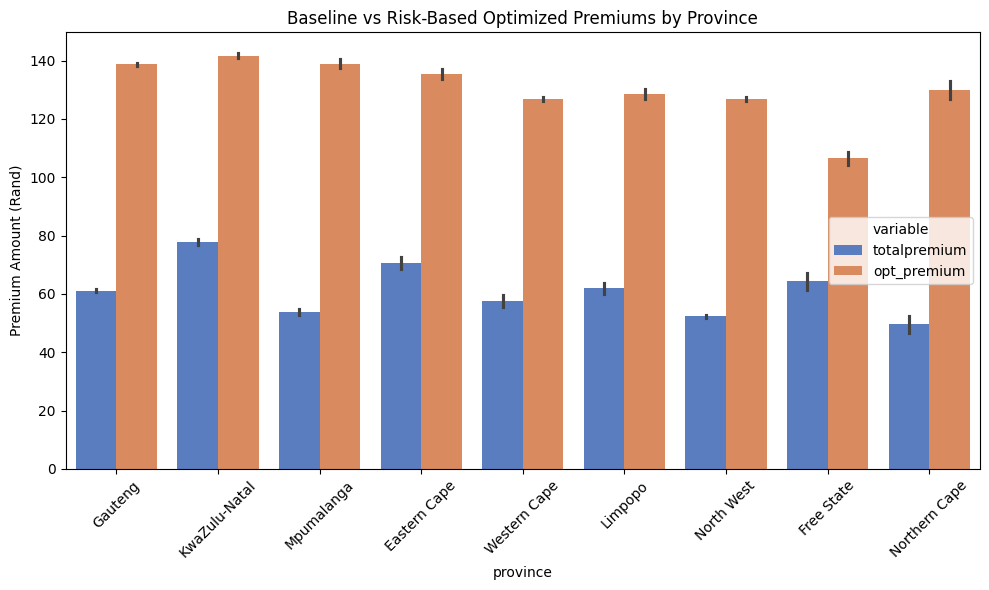

In [9]:
prov_pricing = df.groupby('province')[['totalpremium', 'opt_premium']].mean()
print('Average Premium comparison by Province:')
print(prov_pricing)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df.melt(id_vars='province', value_vars=['totalpremium', 'opt_premium']),
    x='province', y='value', hue='variable', palette='muted'
)
plt.title('Baseline vs Risk-Based Optimized Premiums by Province')
plt.xticks(rotation=45)
plt.ylabel('Premium Amount (Rand)')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/premium_comparison.png', dpi=300)
plt.show()

## 6. Model Interpretability & Feature Importance (SHAP)

I use SHAP (SHapley Additive exPlanations) to explain the feature contributions of the best classification model.

### Interpretation — SHAP Feature Importance:
* **Vehicle Age** has the strongest impact on risk. Newer vehicles drive higher severities (expensive parts), while older vehicles show lower claim likelihoods.
* **Sum Insured** is the key driver of severity — high value assets require significantly larger claim payouts.
* **Province (Gauteng)** pushes the claim probability upward, reinforcing the geographical risk premium found in Task 3.

Computing SHAP values for the best classification model...


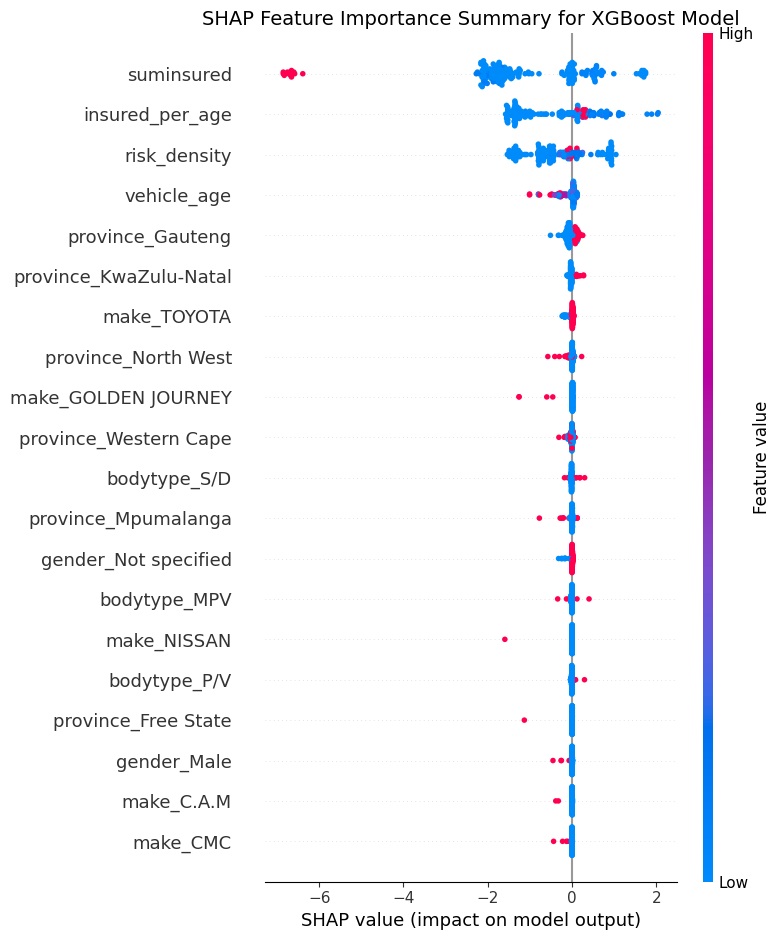

In [10]:
import shap

print('Computing SHAP values for the best classification model...')
X_sample = X_test_cls.iloc[:200].copy()
X_sample_scaled = cls_scaler.transform(X_sample)

explainer = shap.TreeExplainer(best_cls_model)
shap_values = explainer.shap_values(X_sample_scaled)

if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_scaled, feature_names=X_cls.columns, show=False)
plt.title(f'SHAP Feature Importance Summary for {best_cls_name} Model', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/shap_summary_plot.png', dpi=300)
plt.show()

### **Model Interpretability: SHAP Summary**

This plot displays the **SHAP (SHapley Additive exPlanations)** values to explain the XGBoost model's predictions. Features are ranked by overall importance from top to bottom.

* **Dominant Features:** `suminsured`, `risk_density`, `insured_per_age`, and `vehicle_age` exert the strongest influence on the model.
* **Feature Impact:**
  * **High `suminsured`** and **high `insured_per_age`** (magenta) increase the risk representation and predicted severity of assets.
  * **High `risk_density`** (representing high insured value concentrated on newer vehicles) also has a powerful positive impact on the likelihood of claims.
  * **Older `vehicle_age`** (magenta) generally reduces claim probability, whereas newer vehicles carry higher severity/frequency risks.
* **Demographics & Geography:** Provinces (e.g., `Gauteng`, `Western Cape`), marital status, and vehicle makes show minor, localized impacts compared to the core vehicle and insurance exposure metrics.

*Color scale: Magenta = High value, Blue = Low value. X-axis shows the direction and magnitude of the impact.*